In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [11]:
PROCESSED_PATH = "/content/drive/MyDrive/emotion_sentiment_fusion_detector/data/processed"

X_train = np.load(f"{PROCESSED_PATH}/X_train.npy")
X_val = np.load(f"{PROCESSED_PATH}/X_val.npy")
X_test = np.load(f"{PROCESSED_PATH}/X_test.npy")

y_train = np.load(f"{PROCESSED_PATH}/y_train.npy")
y_val = np.load(f"{PROCESSED_PATH}/y_val.npy")
y_test = np.load(f"{PROCESSED_PATH}/y_test.npy")

In [12]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(22967, 48, 48, 1)
(5742, 48, 48, 1)
(7178, 48, 48, 1)
(22967, 7)
(5742, 7)
(7178, 7)


In [13]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# CNN Architecture Design

A Convolutional Neural Network (CNN) is designed to automatically learn visual patterns from images.

The network learns:

- Edges
- Shapes
- Facial structures
- Emotion-specific features

The architecture consists of:

1. Convolution Layers
2. Pooling Layers
3. Flatten Layer
4. Dense Layers
5. Softmax Output Layer

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

# Why Pooling?

Pooling reduces spatial dimensions.

Benefits:

- Faster training
- Less memory usage
- Reduced overfitting

Max Pooling keeps the strongest activation in each region.

In [15]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [16]:
model = Sequential()

# Block 1
model.add(
    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(48,48,1)
    )
)

model.add(
    MaxPooling2D(
        pool_size=(2,2)
    )
)

# Block 2
model.add(
    Conv2D(
        64,
        (3,3),
        activation="relu"
    )
)

model.add(
    MaxPooling2D(
        pool_size=(2,2)
    )
)

# Block 3
model.add(
    Conv2D(
        128,
        (3,3),
        activation="relu"
    )
)

model.add(
    MaxPooling2D(
        pool_size=(2,2)
    )
)

# Classifier
model.add(Flatten())

model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(
    Dropout(
        0.5
    )
)

model.add(
    Dense(
        7,
        activation="softmax"
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

# Model Summary Analysis

The model contains three convolutional blocks.

Feature extraction happens in the convolutional layers.

Classification happens in the dense layers.

The final softmax layer outputs probabilities across the seven emotion classes.

# CNN Architecture Analysis

The model contains 355,847 trainable parameters.

Most parameters are concentrated in the Dense layer after flattening.

The convolutional layers learn hierarchical visual representations:

- Early layers learn edges and simple textures.
- Intermediate layers learn facial structures.
- Deeper layers learn emotion-related features.

Dropout is used to reduce overfitting by randomly disabling neurons during training.

The final softmax layer predicts probabilities across the seven emotion classes.

# Baseline CNN Training

This notebook trains the first emotion recognition model on FER2013.

The objective is to establish a baseline before introducing:

- Data augmentation
- Batch normalization
- Early stopping
- Model checkpointing

Future improvements will be measured against this baseline.

In [19]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64
)

Epoch 1/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.2723 - loss: 1.7739 - val_accuracy: 0.3285 - val_loss: 1.6692
Epoch 2/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3903 - loss: 1.5661 - val_accuracy: 0.4509 - val_loss: 1.4441
Epoch 3/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4477 - loss: 1.4339 - val_accuracy: 0.4862 - val_loss: 1.3375
Epoch 4/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4879 - loss: 1.3456 - val_accuracy: 0.5070 - val_loss: 1.2816
Epoch 5/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5133 - loss: 1.2934 - val_accuracy: 0.5261 - val_loss: 1.2469
Epoch 6/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5277 - loss: 1.2501 - val_accuracy: 0.5362 - val_loss: 1.2248
Epoch 7/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5482 - loss: 1.2008 - val_accuracy: 0.5359 - val_loss: 1.2068
Epoch 8/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5631 - loss: 1.1583 - val_accuracy: 

In [21]:
test_loss, test_acc = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", test_acc)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5656 - loss: 1.2665
Test Accuracy: 0.5656171441078186


In [22]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(
    classification_report(
        y_true,
        y_pred_classes
    )
)

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
              precision    recall  f1-score   support

           0       0.48      0.47      0.47       958
           1       0.76      0.20      0.31       111
           2       0.39      0.31      0.35      1024
           3       0.76      0.79      0.78      1774
           4       0.53      0.50      0.52      1233
           5       0.42      0.54      0.47      1247
           6       0.73      0.69      0.71       831

    accuracy                           0.57      7178
   macro avg       0.58      0.50      0.52      7178
weighted avg       0.57      0.57      0.56      7178



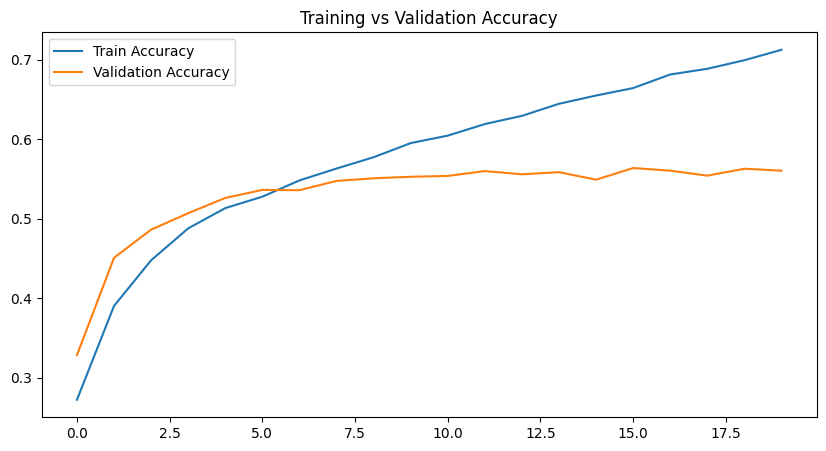

In [23]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.legend()
plt.title("Training vs Validation Accuracy")

plt.show()

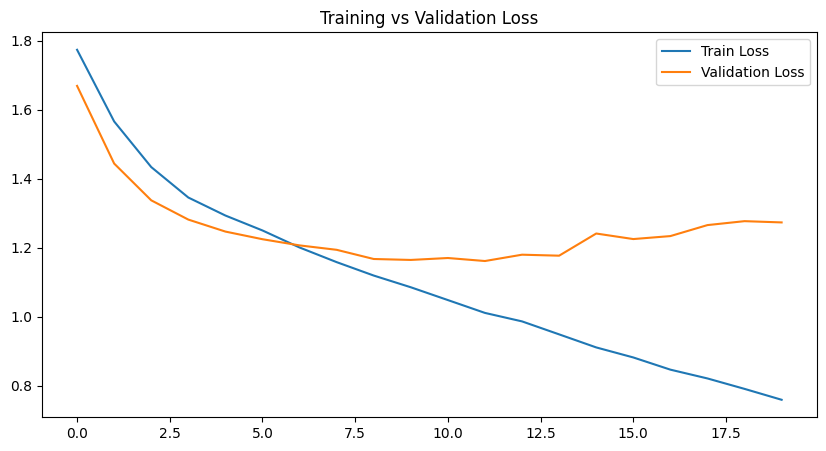

In [24]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.legend()
plt.title("Training vs Validation Loss")

plt.show()

In [27]:
import os

print(os.path.exists(
    "/content/drive/MyDrive/emotion_sentiment_fusion_detector/models"
))

True


In [28]:
import os

os.makedirs(
    "/content/drive/MyDrive/emotion_sentiment_fusion_detector/models/baseline",
    exist_ok=True
)

os.makedirs(
    "/content/drive/MyDrive/emotion_sentiment_fusion_detector/models/improved",
    exist_ok=True
)

In [29]:
model.save(
    "/content/drive/MyDrive/emotion_sentiment_fusion_detector/models/baseline/emotion_baseline.keras"
)

# Baseline CNN Results

## Architecture

Conv2D(32) → MaxPool

Conv2D(64) → MaxPool

Conv2D(128) → MaxPool

Flatten

Dense(128)

Dropout(0.5)

Dense(7)

## Results

Training Accuracy: 71.25%

Validation Accuracy: 56.04%

Observation:

The model learned useful emotion features but showed signs of overfitting, with a significant gap between training and validation accuracy.